## **UMAP: Uniform Manifold Approximation and Projection**

Uniform Manifold Approximation and Projection (UMAP) is a powerful dimension reduction technique that has gained significant traction in the fields of machine learning and data visualization. Developed by Leland McInnes, John Healy, and James Melville, UMAP is built on solid mathematical foundations, including Riemannian geometry and algebraic topology. This article delves into the technical aspects of UMAP, its underlying principles, implementation, and practical applications.

## **Introduction to UMAP**
UMAP is a manifold learning technique that aims to reduce the dimensionality of data while preserving its topological structure. It is particularly useful for visualizing high-dimensional datasets in a low-dimensional space, typically two or three dimensions. UMAP is often compared to t-SNE (t-distributed Stochastic Neighbor Embedding) due to its similar application in data visualization, but it offers several advantages, including better preservation of global data structure and faster computation times.

## **Mathematical Foundations for UMAP**
UMAP is grounded in several key mathematical concepts:

- **Riemannian Manifold:** UMAP assumes that the data is uniformly distributed on a Riemannian manifold. This means that the data points lie on a smooth, curved surface that can be locally approximated by Euclidean space.
- **Riemannian Metric:** The Riemannian metric is locally constant or can be approximated as such. This metric defines the distance between points on the manifold.
- **Topological Data Analysis:** UMAP leverages topological data analysis to capture the structure of the data. It constructs a fuzzy topological representation of the data, which is then optimized to find a low-dimensional embedding.

## **The UMAP Algorithm**
The UMAP algorithm can be broken down into two main phases: constructing a fuzzy topological representation and optimizing the low-dimensional embedding.

### **1. Constructing the Fuzzy Topological Representation**

- **Nearest Neighbor Search:** UMAP begins by finding the nearest neighbors for each data point. This is typically done using approximate nearest neighbor algorithms to speed up the process.
- **Fuzzy Simplicial Set:** A fuzzy simplicial set is constructed from the nearest neighbors. This set captures the local connectivity of the data points.
- **Fuzzy Membership Strengths:** Membership strengths are assigned to the edges of the simplicial set, representing the probability that two points are connected.

### **2. Optimizing the Low-Dimensional Embedding**

- **Cross-Entropy Optimization:** The low-dimensional embedding is optimized to minimize the cross-entropy between the fuzzy simplicial set in the high-dimensional space and the low-dimensional space.
- **Stochastic Gradient Descent:** UMAP uses stochastic gradient descent to perform the optimization. This involves iteratively adjusting the positions of the points in the low-dimensional space to better match the fuzzy topological structure.

## **Practical Implementation of UMAP**
UMAP is implemented in Python and is compatible with the scikit-learn API, making it easy to integrate into existing machine learning pipelines. The following steps outline the basic usage of UMAP:

Installation: UMAP can be installed via conda or pip:
- pip install umap-learn

### **Example 1: UMAP to generate Two-dimensional data**
Let’s see an example about generating 4-dimensional data and using UMAP to generate 2-dimensional data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import umap
%matplotlib inline
sns.set(style='white', context='poster', rc={'figure.figsize':(14,10)})
np.random.seed(44)
data = np.random.rand(700, 4)
fit = umap.UMAP()
%time u = fit.fit_transform(data)

CPU times: total: 18.1 s
Wall time: 11.7 s


- To make the 4-dimensional data “visualizable” we need to generate data uniformly at random from a 4-dimensional cube such that we can interpret a tuple of (R, G, B, a) values specifying a color.
- So while plotting low-dimensional representations each point can be colored according to its 4-dimensional value. We are using numpy for this. And we will use random seed for consistency.
- To find a low dimensional representation of the data we can use the fit_transform() method on a UMAP object.

The resulting value u is a 2-dimensional representation of the data. We can visualise the result by drawing a scatter plot of u. By colouring each point of the scatter plot by the associated 4-dimensional colour from the source data.

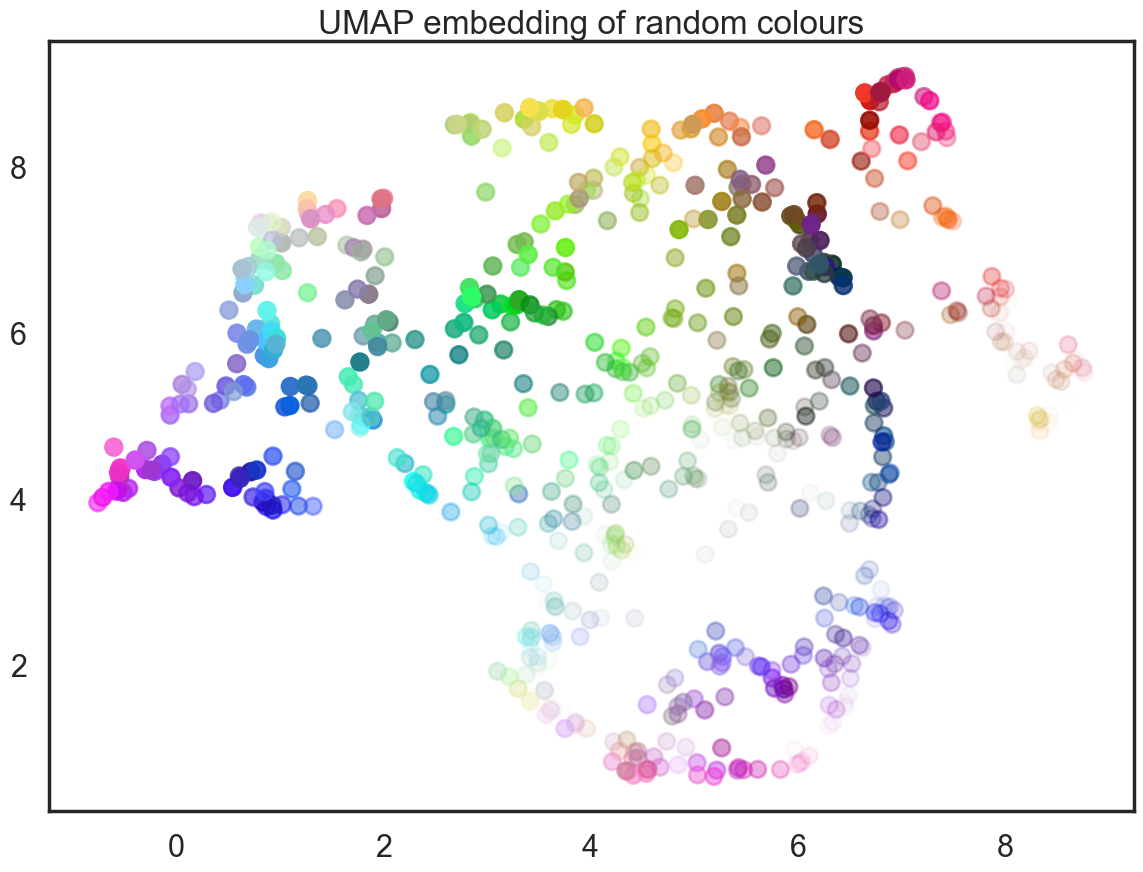

In [2]:
plt.scatter(u[:,0], u[:,1], c=data)
plt.title('UMAP embedding of random colours');

As a result, we can see that the data is placed in 2-dimensional space and the points that were in 4-dimensional space are of similar colors and kept close together.

### **Example 2: UMAP to Reduce the Dimensionality**

Here is a simple example of using UMAP to reduce the dimensionality of the digits dataset from scikit-learn:

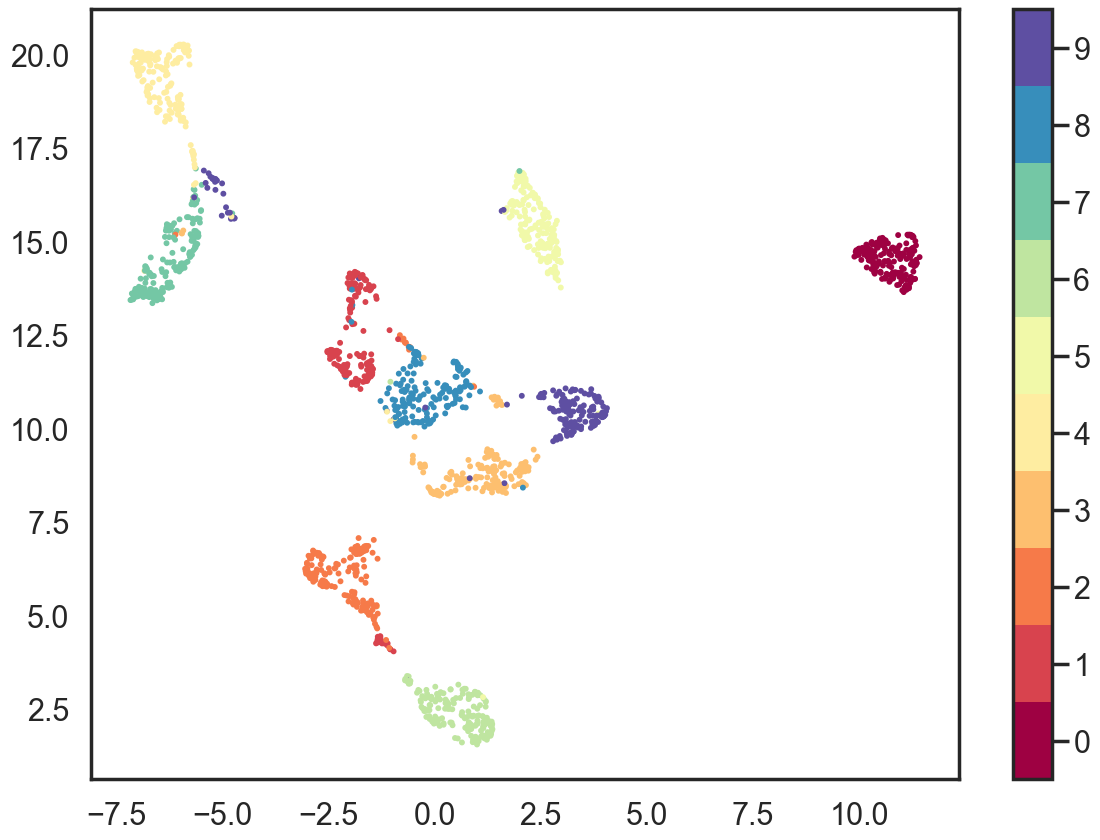

In [3]:
import numpy as np
import umap
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

digits = load_digits()
data = digits.data
scaler = StandardScaler()
data = scaler.fit_transform(data)

# Apply UMAP
reducer = umap.UMAP()
embedding = reducer.fit_transform(data)
plt.scatter(embedding[:, 0], embedding[:, 1], c=digits.target, cmap='Spectral', s=5)
plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
plt.show()

## **Advantages of UMAP**
UMAP offers several advantages over other dimension reduction techniques:

- **Scalability:** UMAP is highly scalable and can handle large datasets efficiently.
- **Preservation of Global Structure:** UMAP tends to preserve more of the global structure of the data compared to t-SNE.
- **Flexibility:** UMAP can be used for both visualization and general-purpose dimension reduction, making it a versatile tool in the data scientist's toolkit.

## **Advanced Usage and Customization**
UMAP offers several advanced features and customization options:

- **Supervised UMAP:** UMAP can be used in a supervised manner by providing labels along with the data. This can improve the quality of the embedding for classification tasks.
- **Metric Customization:** UMAP supports various distance metrics, allowing users to choose the most appropriate metric for their data.
- **Embedding Initialization:** Users can provide an initial embedding to guide the optimization process, which can be useful for fine-tuning the results.

## **Conclusion**

UMAP is a powerful and versatile dimension reduction technique that has become a popular tool for data visualization and analysis. Its solid mathematical foundations, scalability, and ability to preserve both local and global data structures make it an excellent choice for a wide range of applications. Whether you are a data scientist, bioinformatician, or machine learning practitioner, UMAP can help you unlock new insights from your high-dimensional data.